In [2]:
# -------------------------------------------
# PHASE 1 - TASK 1: Asset Data Downloader Setup
# This cell installs and imports required libraries.
# -------------------------------------------

# Install yfinance (silent install to keep notebook clean)
!pip install yfinance --quiet

# Import required packages
import yfinance as yf             # Used to download financial data from Yahoo Finance
import pandas as pd               # For data manipulation and export
import os                         # To handle file system paths and folders

In [4]:
# -------------------------------------------
# Define asset universe and configuration
# This includes equities, ETFs, crypto, FX, commodities, and rates
# -------------------------------------------

assets = [
    "AAPL", "MSFT", "SPY", "QQQ",     # Equities & index-tracking ETFs
    "GLD", "USO",                     # Commodities: Gold & Oil ETFs
    "BTC-USD", "ETH-USD",            # Crypto: Bitcoin & Ethereum
    "EURUSD=X", "USDJPY=X",          # Forex pairs
    "TLT", "VIXY"                     # Bonds (long-duration), Volatility hedge ETF
]

# Define time window for historical data
start_date = "2011-4-29"
end_date = "2025-4-29"

# Define output directory for downloaded CSVs
output_dir = "../data/raw"
os.makedirs(output_dir, exist_ok=True)  # Create the directory if it doesn't exist

In [12]:
# -------------------------------------------
# PHASE 1 - TASK 1 CONTINUED:
# Download and save historical OHLCV data for each asset
# This version ensures flat, clean headers and proper 'Date' indexing
# -------------------------------------------

for ticker in assets:
    print(f"📥 Downloading {ticker}...")
    
    try:
        # Download historical data
        df = yf.download(ticker, start=start_date, end=end_date)

        if not df.empty:
            # Ensure column names are single-level and clean
            df.columns.name = None
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

            # Save as CSV with 'Date' as the index label
            output_path = f"{output_dir}/{ticker}.csv"
            df.to_csv(output_path, index_label="Date")
            print(f"✅ Saved: {output_path}")

        else:
            print(f"⚠️ No data returned for {ticker} — possibly invalid or delisted.")

    except Exception as e:
        print(f"❌ Error downloading {ticker}: {e}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

📥 Downloading AAPL...
✅ Saved: ../data/raw/AAPL.csv
📥 Downloading MSFT...



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

✅ Saved: ../data/raw/MSFT.csv
📥 Downloading SPY...
✅ Saved: ../data/raw/SPY.csv
📥 Downloading QQQ...
✅ Saved: ../data/raw/QQQ.csv
📥 Downloading GLD...



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


✅ Saved: ../data/raw/GLD.csv
📥 Downloading USO...
✅ Saved: ../data/raw/USO.csv
📥 Downloading BTC-USD...
✅ Saved: ../data/raw/BTC-USD.csv
📥 Downloading ETH-USD...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


✅ Saved: ../data/raw/ETH-USD.csv
📥 Downloading EURUSD=X...
✅ Saved: ../data/raw/EURUSD=X.csv
📥 Downloading USDJPY=X...
✅ Saved: ../data/raw/USDJPY=X.csv
📥 Downloading TLT...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

✅ Saved: ../data/raw/TLT.csv
📥 Downloading VIXY...
✅ Saved: ../data/raw/VIXY.csv


In [14]:
# -------------------------------------------
# PHASE 1 - TASK 2: Data Validation
# Step 1: Load each cleaned CSV into a dictionary of DataFrames
# This ensures consistent structure and makes it easy to batch process assets
# -------------------------------------------

from glob import glob

# Path to all cleaned raw asset CSVs
raw_data_path = "../data/raw/*.csv"
csv_files = glob(raw_data_path)

data_dict = {}

for file_path in csv_files:
    ticker = os.path.basename(file_path).replace(".csv", "")
    
    try:
        # Read the CSV with 'Date' as the datetime index
        df = pd.read_csv(file_path, parse_dates=["Date"], index_col="Date")
        
        # Confirm the structure
        if "Close" not in df.columns or df.empty:
            print(f"⚠️ {ticker} may have missing or malformed data.")
        else:
            data_dict[ticker] = df
            print(f"✅ {ticker} loaded: {df.shape}")

    except Exception as e:
        print(f"❌ Failed to load {ticker}: {e}")

✅ AAPL loaded: (3520, 5)
✅ BTC-USD loaded: (3877, 5)
✅ ETH-USD loaded: (2728, 5)
✅ EURUSD=X loaded: (3644, 5)
✅ GLD loaded: (3520, 5)
✅ MSFT loaded: (3520, 5)
✅ QQQ loaded: (3520, 5)
✅ SPY loaded: (3520, 5)
✅ TLT loaded: (3520, 5)
✅ USDJPY=X loaded: (3645, 5)
✅ USO loaded: (3520, 5)
✅ VIXY loaded: (3520, 5)


In [16]:
# -------------------------------------------
# PHASE 1 - TASK 2 CONTINUED
# Step 2: Create a validation summary table
# This captures data health metrics for each asset: start/end date, missing values, etc.
# -------------------------------------------

summary = []

for ticker, df in data_dict.items():
    total_rows = df.shape[0]
    start_date = df.index.min().date()
    end_date = df.index.max().date()
    missing_rows = df.isnull().any(axis=1).sum()
    percent_missing = round((missing_rows / total_rows) * 100, 2)

    summary.append({
        "Ticker": ticker,
        "Start Date": start_date,
        "End Date": end_date,
        "Total Rows": total_rows,
        "Missing Rows": missing_rows,
        "Percent Missing": percent_missing
    })

# Sort by worst data quality (most missing) for inspection
summary_df = pd.DataFrame(summary).sort_values("Percent Missing", ascending=False)
summary_df.reset_index(drop=True, inplace=True)
summary_df

,Ticker,Start Date,End Date,Total Rows,Missing Rows,Percent Missing
0,AAPL,2011-04-29,2025-04-28,3520,0,0.0
1,BTC-USD,2014-09-17,2025-04-28,3877,0,0.0
2,ETH-USD,2017-11-09,2025-04-28,2728,0,0.0
3,EURUSD=X,2011-04-29,2025-04-28,3644,0,0.0
4,GLD,2011-04-29,2025-04-28,3520,0,0.0
5,MSFT,2011-04-29,2025-04-28,3520,0,0.0
6,QQQ,2011-04-29,2025-04-28,3520,0,0.0
7,SPY,2011-04-29,2025-04-28,3520,0,0.0
8,TLT,2011-04-29,2025-04-28,3520,0,0.0
9,USDJPY=X,2011-04-29,2025-04-28,3645,0,0.0


In [18]:
# -------------------------------------------
# PHASE 1 - TASK 2 CONTINUED
# Step 3: Save the validation summary as a metadata CSV
# This file will serve as a record of data quality for downstream reference
# -------------------------------------------

# Create metadata folder if it doesn't exist
metadata_path = "../data/raw/metadata"
os.makedirs(metadata_path, exist_ok=True)

# Save summary table to CSV
summary_df.to_csv(f"{metadata_path}/summary.csv", index=False)
print("✅ Metadata summary saved to data/raw/metadata/summary.csv")

✅ Metadata summary saved to data/raw/metadata/summary.csv


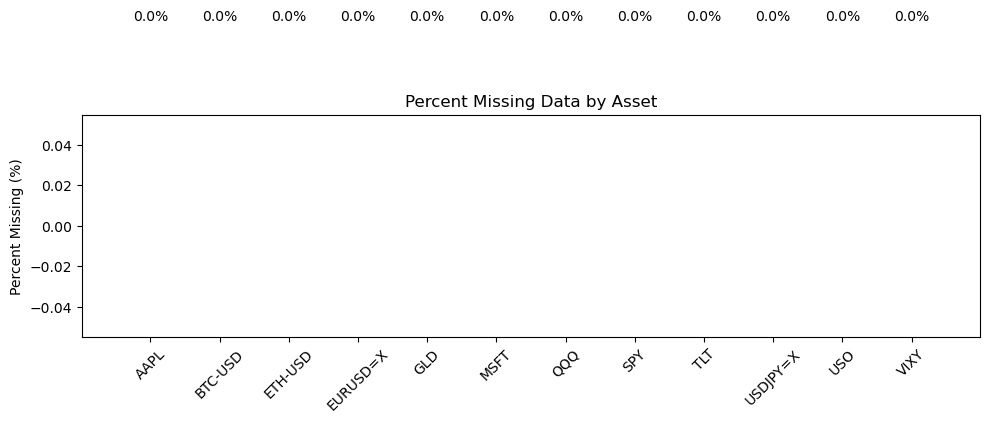

In [20]:
# -------------------------------------------
# PHASE 1 - TASK 2 (Optional Visualization)
# Step 4: Visualize missing data percentage for all assets
# Even though we currently have 0% missing, this is useful for future assets or anomalies
# -------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
bars = plt.bar(summary_df["Ticker"], summary_df["Percent Missing"], color="darkred")

# Label bars with values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.1, f"{yval:.1f}%", ha='center', va='bottom')

plt.title("Percent Missing Data by Asset")
plt.ylabel("Percent Missing (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# -------------------------------------------
# PHASE 1 - TASK 3: Return Calculation
# Step 1: Calculate log returns and align assets by shared date index
# -------------------------------------------

import numpy as np  # Ensure NumPy is available for log calculations

# Function to compute log returns from a price series
def compute_log_returns(prices: pd.Series) -> pd.Series:
    """
    Computes natural log returns of a price series.
    Handles division by shifting and applies element-wise log.
    """
    return (prices / prices.shift(1)).apply(np.log)

# Create an empty DataFrame to collect aligned log returns
returns_df = pd.DataFrame()

# Loop through each asset and compute its log return series
for ticker, df in data_dict.items():
    # Use 'Adj Close' if available, else fall back to 'Close'
    price_col = "Adj Close" if "Adj Close" in df.columns else "Close"
    
    # Compute log returns for this asset
    log_returns = compute_log_returns(df[price_col])

    # Store in returns_df under the asset's ticker name
    returns_df[ticker] = log_returns

# Drop rows with NaNs (from missing price or initial shift)
aligned_returns = returns_df.dropna()

# Preview the aligned return matrix
aligned_returns.head()

,AAPL,BTC-USD,ETH-USD,EURUSD=X,GLD,MSFT,QQQ,SPY,TLT,USDJPY=X,USO,VIXY
Date,,,,,,,,,,,,
2017-11-10,-0.003315,-0.076400,-0.069790,0.004300,-0.008222,-0.002620,-0.000065,-0.000310,-0.015194,-0.004857,-0.003497,0.022040
2017-11-13,-0.004015,0.097510,0.028204,0.001224,0.001485,0.000715,0.001236,0.000929,0.002093,0.002739,-0.003509,0.003109
2017-11-14,-0.015233,0.011559,0.063948,0.000327,0.002059,0.001429,-0.003646,-0.002325,0.006732,-0.000889,-0.022213,0.007903
2017-11-15,-0.013278,0.097529,-0.012740,0.010908,-0.001235,-0.007803,-0.004707,-0.005018,0.010804,-0.001612,-0.003600,0.035964
2017-11-17,-0.005568,-0.020886,0.004432,-0.001308,0.011955,-0.009662,-0.003825,-0.002943,0.007385,-0.003303,0.024979,-0.015956


In [26]:
# -------------------------------------------
# PHASE 1 - TASK 3: Return Calculation (Final Step)
# Step 2: Save aligned log returns to data/processed/returns.parquet
# -------------------------------------------

# Create the processed data folder if it doesn't exist
processed_path = "../data/processed"
os.makedirs(processed_path, exist_ok=True)

# Save as Parquet (efficient binary format for numerical data)
aligned_returns.to_parquet(f"{processed_path}/returns.parquet")

print("✅ Aligned return matrix saved to data/processed/returns.parquet")

✅ Aligned return matrix saved to data/processed/returns.parquet


In [28]:
# Save installed packages to requirements.txt in the root project folder
!pip freeze > ../requirements.txt